In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings. filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
# Set a random seed so our results are reproducible
# (without this, the train/test split would be different every time we run)
RANDOM_STATE = 42

In [2]:
# Load the cleaned master data
import pandas as pd

DATA_PATH = "adelaide_master.csv"
df = pd.read_csv(DATA_PATH, dtype={'SA2_CODE_2021': str})

print(f"Loaded {len(df)} suburbs × {len(df.columns)} columns")
print(f"Columns: {list(df.columns)}")
df.head()

Loaded 112 suburbs × 10 columns
Columns: ['SA2_CODE_2021', 'SA2_NAME_2021', 'SA3_NAME', 'median_age', 'weekly_personal_income', 'weekly_household_income', 'weekly_rent', 'avg_household_size', 'population', 'bunnings_count']


,SA2_CODE_2021,SA2_NAME_2021,SA3_NAME,median_age,weekly_personal_income,weekly_household_income,weekly_rent,avg_household_size,population,bunnings_count
0,401011001,Adelaide,Adelaide City,31,726,1365,400,1.8,18202,0
1,401011002,North Adelaide,Adelaide City,39,964,1867,390,1.9,6823,0
2,401021003,Adelaide Hills,Adelaide Hills,47,792,1905,300,2.7,7051,0
3,401021004,Aldgate - Stirling,Adelaide Hills,44,993,2297,410,2.7,18208,0
4,401021005,Hahndorf - Echunga,Adelaide Hills,48,804,1926,345,2.6,4726,0


In [3]:
# target what we are trying to predict is assigning 1 to have Bunnings in that suburb and else 0
df['has_bunnings']=(df['bunnings_count']>0).astype(int) #it takes column bunnings_count and compare if it is >0 and assign true andfalse as we use.astype(int) they chages to 0 if false and 1 if it is true
print("Target distribution")
print(df['has_bunnings'].value_counts())
print(f"\nPositive class rate: {df['has_bunnings'].mean():.1%}")

Target distribution
has_bunnings
0    96
1    16
Name: count, dtype: int64

Positive class rate: 14.3%


In [4]:
# we need to select which columns should be model using and which shouldn't
# bunnings_count : direct leakage
excluded_cols=['SA2_CODE_2021',
    'SA2_NAME_2021',
    'SA3_NAME',
    'bunnings_count',
    'has_bunnings'
]

feature_cols=[c for c in df.columns if c not in excluded_cols]


print("Features the model will use:")
for f in feature_cols:
    print(f"   • {f}")
print(f"\nTotal features: {len(feature_cols)}")

Features the model will use:
   • median_age
   • weekly_personal_income
   • weekly_household_income
   • weekly_rent
   • avg_household_size
   • population

Total features: 6


In [5]:
# we need to build feature matrix as x= inputs(features) and y=targets this is the standard ML convention
x=df[feature_cols].copy()
y= df['has_bunnings'].copy()
# for demographic data medain is always right choice because one billionaire in suburb skewa mean widely but median ignore them
# we need to handle any missing values and replacing each Nan with medain of that column
x=x.fillna(x.median(numeric_only=True))
x.describe().round(2)

,median_age,weekly_personal_income,weekly_household_income,weekly_rent,avg_household_size,population
count,112.00,112.00,112.00,112.00,112.00,112.00
mean,40.04,780.73,1558.09,307.82,2.37,12386.39
std,7.82,289.38,449.38,82.63,0.52,6163.66
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,37.00,687.00,1362.50,300.00,2.30,7971.75
50%,40.00,778.00,1589.50,320.00,2.50,13042.50
75%,43.00,844.75,1869.25,350.00,2.60,16731.75
max,67.00,3250.00,2326.00,420.00,2.90,26480.00


In [6]:
# as we are getting min values as 0 we need to investigate and we are figuring out how many rows we have and in which suburbs
suspect = df[
    (df['population'] == 0) | 
    (df['median_age'] == 0) | 
    (df['weekly_household_income'] == 0)
]
print(f"Number of suspect rows: {len(suspect)}")

print(suspect[['SA2_NAME_2021', 'SA3_NAME', 'population', 'median_age', 
               'weekly_household_income', 'has_bunnings']].to_string(index=False))
# as we are getting this result we need to drop those rows beacuse they can mislead model and two them has store where the population is very low 
# so we need to rerun the abve tasks again to get accuaret data

Number of suspect rows: 5
         SA2_NAME_2021             SA3_NAME  population  median_age  weekly_household_income  has_bunnings
     Dry Creek - North            Salisbury           0           0                        0             0
             Parafield            Salisbury          21          22                        0             1
Happy Valley Reservoir          Onkaparinga           0          67                     1375             0
     Dry Creek - South Port Adelaide - West           0           0                        0             0
      Adelaide Airport         West Torrens           4          51                        0             1


In [7]:
# as those two zones which showing has bunnings are airport and industrial area where there will be no pulation lives there
before= len(df)
df=df[df['population']>0].copy()
# droping suburbs
df=df[df['population']>100].copy()
after= len(df)
print(f"Before filter: {before} suburbs")
print(f"After filter:  {after} suburbs")
print(f"Dropped:       {before - after} non-residential SA2s")

print(f"\nNew target distribution:")
print(df['has_bunnings'].value_counts())
print(f"Positive rate: {df['has_bunnings'].mean():.1%}")

Before filter: 112 suburbs
After filter:  105 suburbs
Dropped:       7 non-residential SA2s

New target distribution:
has_bunnings
0    91
1    14
Name: count, dtype: int64
Positive rate: 13.3%


In [8]:
#now we need to rebuild our  matrix x and y
x=df[feature_cols].copy()
y= df['has_bunnings'].copy()
x=x.fillna(x.median(numeric_only=True))
x.describe().round(2)

,median_age,weekly_personal_income,weekly_household_income,weekly_rent,avg_household_size,population
count,105.00,105.00,105.00,105.00,105.00,105.00
mean,40.30,782.32,1634.83,326.53,2.48,13211.66
std,4.12,122.44,320.82,36.52,0.20,5435.62
min,29.00,460.00,827.00,225.00,1.80,2473.00
25%,37.00,698.00,1421.00,300.00,2.30,9448.00
50%,40.00,787.00,1635.00,320.00,2.50,13515.00
75%,43.00,847.00,1879.00,350.00,2.60,17496.00
max,51.00,1001.00,2326.00,420.00,2.90,26480.00


In [9]:
# now we need to train model as spliting 80% training data and 20% as test data
#we use stratify= preserve same positive/negative ratio in both sets
from sklearn.model_selection import train_test_split
RANDOM_STATE =42 # any number that makes split reproducible across runs
x_train,x_test,y_train,y_test= train_test_split(x,y,
                                                test_size=0.2,
                                                stratify=y,
                                                random_state=RANDOM_STATE)
                                                
print(f"Training set: {len(x_train)} suburbs ({y_train.sum()} positives)")
print(f"Test set:     {len(x_test)} suburbs ({y_test.sum()} positives)")
print(f"\nTrain positive rate: {y_train.mean():.1%}")
print(f"Test  positive rate: {y_test.mean():.1%}")

Training set: 84 suburbs (11 positives)
Test set:     21 suburbs (3 positives)

Train positive rate: 13.1%
Test  positive rate: 14.3%


In [10]:
# no we use dummy classisfier as sumbest possible model
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, accuracy_score
dummy=DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(x_train,y_train)
y_pred_dummy=dummy.predict(x_test)
y_proba_dummy=dummy.predict_proba(x_test)[:,1]
print(f"Accuracy: {accuracy_score(y_test, y_pred_dummy):.3f}")
print(f"AUC:      {roc_auc_score(y_test, y_proba_dummy):.3f}")

Accuracy: 0.857
AUC:      0.500


almost 86% accuarcy is good but auc has random 0.500  which is useless 

for this see dairy note 30/04/2026

predict() is returning binary values as 0/1 
predict_proba() is returning probabilities for both classes as [[0.86,0.14],[0.86,0.14]] and [:,1] means taking only second column which is has_bunnings
for auc we always use probabilities not binary predections which it will rank things bassed on that.

In [11]:
y_proba_full =model_lr.predict_proba(x_test)

NameError: name 'model_lr' is not defined

In [ ]:
# now we again need to sanity check for our dummy model whether it gives random probability and auc score close to 0.55
np.random.seed(RANDOM_STATE)
random_proba=np.random.rand(len(x_test))
print(f" AUC: {roc_auc_score(y_test,random_proba):.3f}")

In [ ]:
# now we need to save train/test splits to disk to use in future of the project without re-running evrything again
import os
processed_dir = '../data/processed'
os.makedirs(processed_dir, exist_ok=True)# creates folder if doesn't a;ready exist and exist_ok=True means if it exists just continue not to show error
# os.path.join(processed_dir, 'x_train.csv')--combines folderpath with file name
# index=False don't include row index numbers 
x_train.to_csv(os.path.join(processed_dir, 'x_train.csv'), index=False)
x_test.to_csv(os.path.join(processed_dir, 'x_test.csv'), index=False)
y_train.to_csv(os.path.join(processed_dir, 'y_train.csv'), index=False)
y_test.to_csv(os.path.join(processed_dir, 'y_test.csv'), index=False)

print(f" Train/test splits saved to:")
print(f"   {processed_dir}")
print(f"\nFiles:")
print(f"   • x_train.csv  ({x_train.shape[0]} rows, {x_train.shape[1]} cols)")
print(f"   • x_test.csv   ({x_test.shape[0]} rows, {x_test.shape[1]} cols)")
print(f"   • y_train.csv  ({y_train.shape[0]} values)")
print(f"   • y_test.csv   ({y_test.shape[0]} values)")

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler # this StandardScaler is used to put features on the same scale
from sklearn.metrics import roc_auc_score, classification_report # classification_report gives nice summary of metrics
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)# fit -looks at x_train and computes mean and std of each feauture coulumn
# transform -uses stored values to convert scaled_value = (raw_value-mean)/std
x_test_scaled=scaler.transform(x_test) # always use fit_transform on train and transform on test
# Define train model
model_lr=LogisticRegression(class_weight='balanced',
                            random_state=RANDOM_STATE,
                            max_iter=1000) # how many iterations does model should perform
model_lr.fit(x_train_scaled,y_train) # fit(x,y) kicks off gradient descent
# intialise beta values randomly-->compute predictions on training rows-->compute totalloss vs y_train
#--> adjust beta values to reduce loss--> repeat until loss stops improving
# at the end model_lr stores optimal beta values internally in model_lr.coef
# and model_lr.intercept --store beta intercept
y_pred_lr=model_lr.predict(x_test_scaled)
# computes beta values and applies sigmoid to get probability and if probability>=0.5 predicts 1
y_proba_lr=model_lr.predict_proba(x_test_scaled)[:,1]
#we use 2D array as (P(class0),P(class1))- but we use only [:,1] which is P(class1)
#returns array of 21 probabilities which has bunnings
print(f"test AUC : {roc_auc_score(y_test,y_proba_lr):.3f}")
print(classification_report(y_test,y_pred_lr,target_names=["No Bunnings","Has Bunnings"]))



test AUC : 0.889
              precision    recall  f1-score   support

 No Bunnings       1.00      0.61      0.76        18
Has Bunnings       0.30      1.00      0.46         3

    accuracy                           0.67        21
   macro avg       0.65      0.81      0.61        21
weighted avg       0.90      0.67      0.72        21



In [13]:
# now we need to check what did model actually learn
import pandas as pd
coef_df=pd.DataFrame({'feature': feature_cols,
                      'coefficient': model_lr.coef_[0] # list of 6beta values model learned model_lr.coef is 2D array bit coef[0] gives 1D array values that have 6 beta values
                     }).sort_values('coefficient', ascending=False)

print(f"Intercept (β₀): {model_lr.intercept_[0]:.3f}\n")
print(coef_df.to_string(index=False))

Intercept (β₀): -0.880

                feature  coefficient
             population     0.670633
 weekly_personal_income     0.604287
            weekly_rent     0.346221
     avg_household_size    -0.838004
             median_age    -0.881093
weekly_household_income    -0.969367


In [14]:
# as we know that weekly_household_income and avg_hh_income are related but it showing differently
#checking for correlation between feature
import pandas as pd
print("correlation matrix:")
print(x.corr().round(2))


correlation matrix:
                         median_age  weekly_personal_income  \
median_age                     1.00                    0.40   
weekly_personal_income         0.40                    1.00   
weekly_household_income        0.43                    0.90   
weekly_rent                    0.27                    0.75   
avg_household_size            -0.06                    0.02   
population                    -0.37                   -0.13   

                         weekly_household_income  weekly_rent  \
median_age                                  0.43         0.27   
weekly_personal_income                      0.90         0.75   
weekly_household_income                     1.00         0.73   
weekly_rent                                 0.73         1.00   
avg_household_size                          0.37         0.01   
population                                 -0.26        -0.07   

                         avg_household_size  population  
median_age              

In [15]:
# as we got multicollinearity fo now we are dropping highly correlated features
reduced_features=[c for c in feature_cols
                  if c not in ['weekly_personal_income','weekly_rent']]
for f in reduced_features:
    print(f" .{f}")
# rebuild x with reduced features
x_reduced=df[reduced_features].copy()
x_reduced=x_reduced.fillna(x_reduced.median(numeric_only=True))
# redo train/split on reduced fetures
from sklearn.model_selection import train_test_split
x_train_r,x_test_r,y_train_r,y_test_r=train_test_split(
    x_reduced,y,test_size=0.2,stratify=y, random_state=RANDOM_STATE)
# rescale
scaler_r=StandardScaler()
x_train_r_scaled=scaler_r.fit_transform(x_train_r)
x_test_r_scaled=scaler_r.transform(x_test_r)
#retrain
model_lr_reduced = LogisticRegression(class_weight='balanced', 
                                      random_state=RANDOM_STATE,
                                      max_iter=1000)
model_lr_reduced.fit(x_train_r_scaled, y_train_r)
y_pred_reduced_lr=model_lr_reduced.predict(x_test_r_scaled)
y_proba_reduced_lr = model_lr_reduced.predict_proba(x_test_r_scaled)[:, 1]


print(f"\n=== REDUCED MODEL (4 features, no multicollinearity) ===")
print(f"Test AUC: {roc_auc_score(y_test_r, y_proba_reduced_lr):.3f}")
print(f"\nCoefficients:")
for feat, coef in zip(reduced_features, model_lr_reduced.coef_[0]): # zip takes two lists together and pair them up by elemrnt-by-element
    print(f"   {feat:30s}  {coef:+.3f}")

 .median_age
 .weekly_household_income
 .avg_household_size
 .population

=== REDUCED MODEL (4 features, no multicollinearity) ===
Test AUC: 0.796

Coefficients:
   median_age                      -0.902
   weekly_household_income         -0.121
   avg_household_size              -1.065
   population                      +0.626


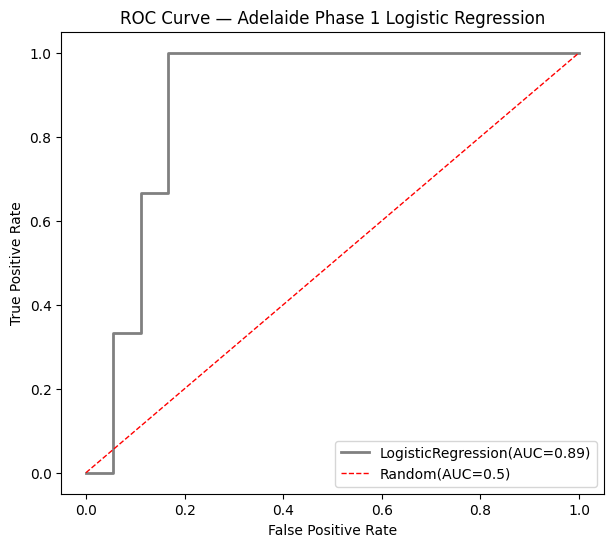

In [16]:
#plot Roc curve
from sklearn.metrics import roc_curve
import os
fpr,tpr,_=roc_curve(y_test,y_proba_lr) #'_' is thesholds in this case that is ignored

plt.figure(figsize=(7,6))
plt.plot(fpr,tpr,color='grey',lw=2,
         label=f'LogisticRegression(AUC={roc_auc_score(y_test,y_proba_lr):.2f})')
plt.plot([0,1],[0,1],color='red',lw=1,linestyle='--',label='Random(AUC=0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Adelaide Phase 1 Logistic Regression')
plt.legend(loc='lower right')

#reports_dir = r'C:\Users\kiran\bunnings-project\data-science-version\reports'
#os.makedirs(reports_dir, exist_ok=True)
#plt.savefig(os.path.join(reports_dir, 'phase1_roc.png'), dpi=150, bbox_inches='tight')
plt.show()

FPR- false positve rate as actual negatives, how many did model wrongly flag as positive
TPR- True positive rate as actual positives, how many did model correctly catch


In [17]:
unserved_mask=df['has_bunnings']==0 # it checks suburb with zero bunnings and give true/false
unserved=df[unserved_mask].copy()
# now we use features for prediction
x_unserved=unserved[feature_cols].fillna(unserved[feature_cols] .median (numeric_only=True))
x_unserved_scaled=scaler.transform(x_unserved)
#generate predictions we will get 2D array values of class0 and class1 so we used[:,1] to get class1 which has bunnings
unserved['p_bunnings']=model_lr.predict_proba(x_unserved_scaled)[:,1]
top_suburbs=unserved.sort_values('p_bunnings', ascending=False).head(5)
display_cols = ['SA2_NAME_2021','SA3_NAME','population',
                'weekly_household_income','p_bunnings']
print(top_suburbs[display_cols].to_string(index=False))


        SA2_NAME_2021             SA3_NAME  population  weekly_household_income  p_bunnings
             Adelaide        Adelaide City       18202                     1365    0.997185
             Plympton         West Torrens       26480                     1551    0.929164
       North Adelaide        Adelaide City        6823                     1867    0.871886
 Hindmarsh - Brompton        Charles Sturt       19076                     1631    0.846165
Enfield - Blair Athol Port Adelaide - East       25578                     1428    0.805404
